In [1]:
# Импорт библиотек
import os
import json
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import torch.nn as nn
import copy
import time
import csv

# Фиксируем seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed зафиксирован: {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

test_tensor = torch.randn(2, 3, 32, 32).to(device)
assert test_tensor.device.type == device.type, "Тензор не на целевом устройстве!"
print(f"Тестовый тензор создан на устройстве: {test_tensor.device}")

Seed зафиксирован: 42
Используемое устройство: cpu
Тестовый тензор создан на устройстве: cpu


In [2]:
# Выбор датасета часть A
DATASET_A = "STL10"

# Выбор датасета часть B
DATASET_B = "PascalVOC"
TASK_B = "detection"

DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(exist_ok=True)

print(f"Датасет Части A: {DATASET_A}")
print(f"Датасет Части B: {DATASET_B} ({TASK_B})")

Датасет Части A: STL10
Датасет Части B: PascalVOC (detection)


In [3]:
# Transforms для Части A
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Базовый transform для CNN (C1)
base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transform с аугментациями (C2)
aug_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Preprocessing для ResNet (C3, C4)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform для validation/test (обычной CNN)
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transform для validation/test ResNet
val_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


In [4]:
# Загрузка STL10
train_dataset_full = datasets.STL10(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=aug_transform
)

test_dataset = datasets.STL10(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=val_transform
)

# Разделение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Датасеты для ResNet
train_dataset_resnet = datasets.STL10(
    root=DATA_ROOT,
    split="train",
    download=False,
    transform=resnet_transform
)

val_dataset_resnet, _ = torch.utils.data.random_split(
    train_dataset_resnet,
    [val_size, train_size],
    generator=torch.Generator().manual_seed(SEED)
)

test_dataset_resnet = datasets.STL10(
    root=DATA_ROOT,
    split="test",
    download=False,
    transform=val_transform_resnet
)

# DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 2.64G/2.64G [01:41<00:00, 25.9MB/s]


Train: 4000, Val: 1000, Test: 8000


In [5]:
# Загрузка Pascal VOC Detection
from torchvision.datasets import VOCDetection

voc_train = VOCDetection(
    root=DATA_ROOT,
    year="2012",
    image_set="train",
    download=True,
    transform=transforms.ToTensor()
)

voc_test = VOCDetection(
    root=DATA_ROOT,
    year="2012",
    image_set="val",
    download=True,
    transform=transforms.ToTensor()
)

voc_loader_train = DataLoader(voc_train, batch_size=4, shuffle=True, num_workers=NUM_WORKERS, collate_fn=lambda x: x)
voc_loader_test = DataLoader(voc_test, batch_size=4, shuffle=False, num_workers=NUM_WORKERS, collate_fn=lambda x: x)

print(f"VOC Train: {len(voc_train)}, VOC Test: {len(voc_test)}")

100%|██████████| 2.00G/2.00G [01:28<00:00, 22.7MB/s]


VOC Train: 5717, VOC Test: 5823


Sanity Check Часть A
Размер батча: 32
Форма изображения: torch.Size([32, 3, 64, 64])
Форма лейблов: torch.Size([32])
Устройство: cuda:0


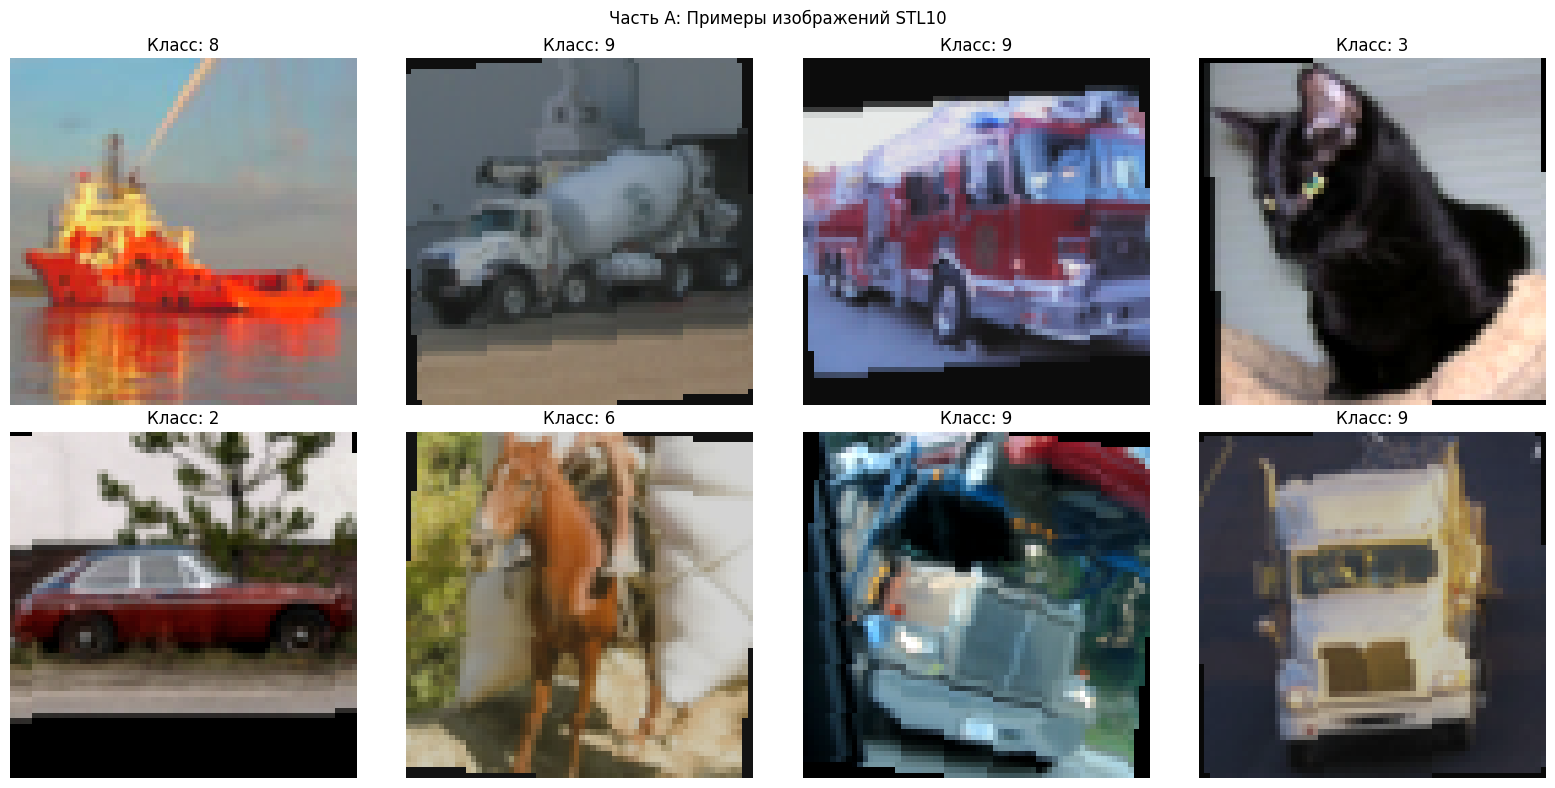


Sanity Check Часть B
dict_keys(['annotation'])
{'annotation': {'filename': '2009_002695.jpg', 'folder': 'VOC2012', 'object': [{'name': 'train', 'bndbox': {'xmax': '500', 'xmin': '1', 'ymax': '261', 'ymin': '151'}, 'difficult': '0', 'occluded': '1', 'pose': 'Unspecified', 'truncated': '1'}, {'name': 'car', 'bndbox': {'xmax': '500', 'xmin': '475', 'ymax': '303', 'ymin': '224'}, 'difficult': '0', 'occluded': '0', 'pose': 'Rear', 'truncated': '1'}, {'name': 'car', 'bndbox': {'xmax': '470', 'xmin': '360', 'ymax': '307', 'ymin': '242'}, 'difficult': '0', 'occluded': '0', 'pose': 'Rear', 'truncated': '0'}, {'name': 'car', 'bndbox': {'xmax': '352', 'xmin': '207', 'ymax': '316', 'ymin': '242'}, 'difficult': '0', 'occluded': '0', 'pose': 'Unspecified', 'truncated': '0'}, {'name': 'car', 'bndbox': {'xmax': '238', 'xmin': '72', 'ymax': '317', 'ymin': '244'}, 'difficult': '0', 'occluded': '1', 'pose': 'Unspecified', 'truncated': '0'}, {'name': 'car', 'bndbox': {'xmax': '30', 'xmin': '1', 'ymax': '

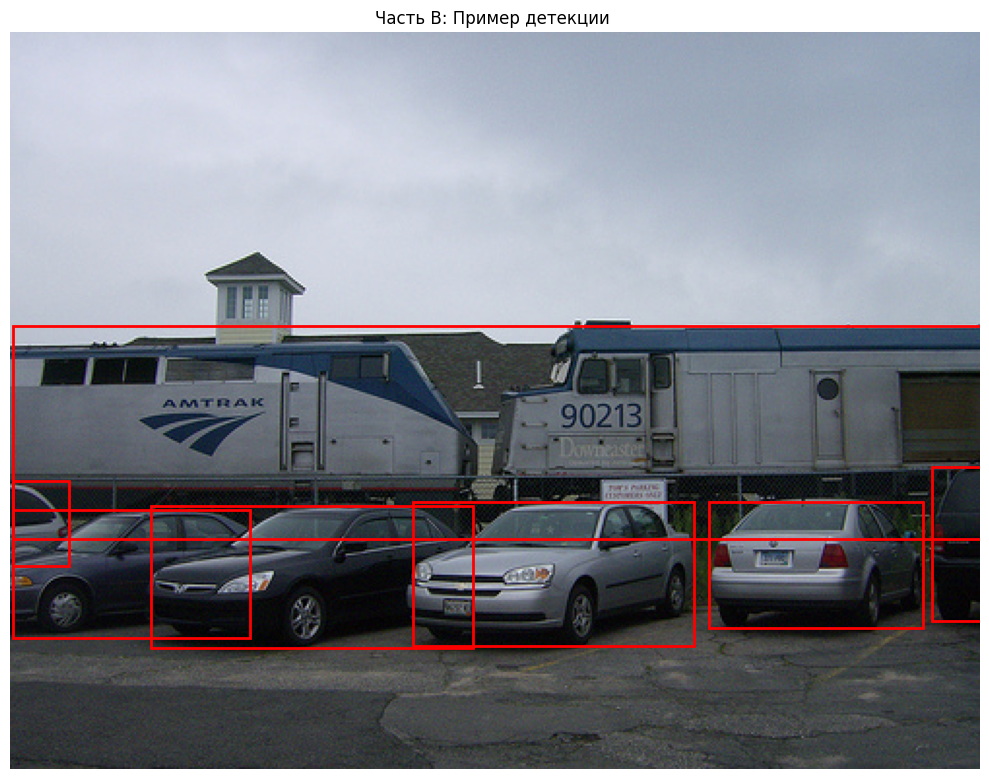


Sanity Check завершён успешно


In [6]:
# Создаём папку для артефактов
Path("artifacts/figures").mkdir(parents=True, exist_ok=True)

# Sanity Check Часть A
batch = next(iter(train_loader))
x, y = batch[0].to(device), batch[1].to(device)

print(f"Sanity Check Часть A")
print(f"Размер батча: {x.shape[0]}")
print(f"Форма изображения: {x.shape}")
print(f"Форма лейблов: {y.shape}")
print(f"Устройство: {x.device}")

# Визуализация Часть A
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(x):
        img = x[i].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5  # Денормализация
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"Класс: {y[i].item()}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle("Часть A: Примеры изображений STL10")
plt.tight_layout()
plt.savefig("artifacts/figures/data_sanity_check.png", dpi=150, bbox_inches='tight')
plt.show()

# Sanity Check Часть B
print(f"\nSanity Check Часть B")
batch_b = next(iter(voc_loader_train))
sample = batch_b[0]
img_b = sample[0]
target_b = sample[1]

print(target_b.keys())
print(target_b)

print(f"Форма изображения: {img_b.shape}")

objects = target_b['annotation']['object']

if not isinstance(objects, list):
    objects = [objects]

boxes = []
labels = []

for obj in objects:
    b = obj['bndbox']
    x1 = float(b['xmin'])
    y1 = float(b['ymin'])
    x2 = float(b['xmax'])
    y2 = float(b['ymax'])

    boxes.append([x1, y1, x2, y2])
    labels.append(obj['name'])

print(f"Количество объектов: {len(boxes)}")
print(f"Охват: {boxes}")
print(f"Классы объектов: {labels}")

# Визуализация Часть B
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
img_np = img_b.permute(1, 2, 0).cpu().numpy()
ax.imshow(img_np)

for box in boxes[:10]:  # Ограничиваем до 10 объектов для визуализации
    x1, y1, x2, y2 = box
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
    ax.add_patch(rect)

ax.set_title("Часть B: Пример детекции ")
ax.axis('off')
plt.tight_layout()
plt.savefig("artifacts/figures/detection_sanity_check.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSanity Check завершён успешно")

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Архитектура SimpleCNN создана")

Архитектура SimpleCNN создана


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Эпоха {epoch} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{100.*correct/total:.2f}%"})

    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100. * correct / total

print("Функции train_one_epoch и evaluate созданы")

Функции train_one_epoch и evaluate созданы


In [9]:

def run_experiment(model, train_loader, val_loader, test_loader, device, experiment_id, epochs=10, lr=0.001):
    print(f"Эксперимент: {experiment_id}")

    model = model.to(device)
    criterion = CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch+1)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        print(f"Эпоха {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Финальная оценка на test
    model.load_state_dict(best_model_state)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"\nЛучшая валидационная точность: {best_val_acc:.2f}%")
    print(f"Тестовая точность: {test_acc:.2f}%")

    results = {
        "experiment_id": experiment_id,
        "epochs_trained": epochs,
        "lr": lr,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "history": history,
        "best_model_state": best_model_state
    }

    return results, model

print("Функция run_experiment создана")

Функция run_experiment создана


In [10]:
# Хранилище результатов
all_results = {}

# C1: Simple CNN без аугментаций
print("ЭКСПЕРИМЕНТ C1: Simple CNN (без аугментаций)")

train_loader_c1 = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
model_c1 = SimpleCNN(num_classes=10)
results_c1, trained_model_c1 = run_experiment(
    model_c1, train_loader_c1, val_loader, test_loader,
    device, "C1", epochs=10, lr=0.001
)
all_results["C1"] = results_c1

# C2: Simple CNN с аугментациями
print("ЭКСПЕРИМЕНТ C2: Simple CNN (с аугментациями)")

train_loader_c2 = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
model_c2 = SimpleCNN(num_classes=10)
results_c2, trained_model_c2 = run_experiment(
    model_c2, train_loader_c2, val_loader, test_loader,
    device, "C2", epochs=10, lr=0.001
)
all_results["C2"] = results_c2

# C3: ResNet18
print("ЭКСПЕРИМЕНТ C3: ResNet18 (head-only)")

model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_c3.parameters():
    param.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)
model_c3.fc.requires_grad = True

results_c3, trained_model_c3 = run_experiment(
    model_c3, train_loader_resnet, val_loader_resnet, test_loader_resnet,
    device, "C3", epochs=10, lr=0.01
)
all_results["C3"] = results_c3

# C4: ResNet18 - fine-tune (layer4 + fc)
print("ЭКСПЕРИМЕНТ C4: ResNet18 (fine-tune)")

model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
model_c4.fc.requires_grad = True

results_c4, trained_model_c4 = run_experiment(
    model_c4, train_loader_resnet, val_loader_resnet, test_loader_resnet,
    device, "C4", epochs=10, lr=0.001
)
all_results["C4"] = results_c4

print("\nВсе эксперименты C1-C4 завершены")

ЭКСПЕРИМЕНТ C1: Simple CNN (без аугментаций)
Эксперимент: C1


Эпоха 1 [Train]: 100%|██████████| 125/125 [00:07<00:00, 16.45it/s, loss=1.8049, acc=24.23%]


Эпоха 1/10 | Train Loss: 2.1877 | Train Acc: 24.23% | Val Loss: 1.9202 | Val Acc: 27.20%


Эпоха 2 [Train]: 100%|██████████| 125/125 [00:05<00:00, 21.42it/s, loss=1.9225, acc=31.62%]


Эпоха 2/10 | Train Loss: 1.7776 | Train Acc: 31.62% | Val Loss: 1.5876 | Val Acc: 39.80%


...

Эпоха 8/10 | Train Loss: 0.0061 | Train Acc: 99.92% | Val Loss: 0.0009 | Val Acc: 100.00%


Эпоха 9 [Train]: 100%|██████████| 157/157 [00:15<00:00, 10.13it/s, loss=0.0230, acc=99.94%]


Эпоха 9/10 | Train Loss: 0.0045 | Train Acc: 99.94% | Val Loss: 0.0007 | Val Acc: 100.00%


Эпоха 10 [Train]: 100%|██████████| 157/157 [00:15<00:00,  9.92it/s, loss=0.0501, acc=99.98%]


Эпоха 10/10 | Train Loss: 0.0039 | Train Acc: 99.98% | Val Loss: 0.0005 | Val Acc: 100.00%

Лучшая валидационная точность: 100.00%
Тестовая точность: 93.66%

Все эксперименты C1-C4 завершены


In [11]:
# Выбор лучшей модели по val_accuracy
best_exp_id = max(all_results.keys(), key=lambda k: all_results[k]["best_val_accuracy"])
best_results = all_results[best_exp_id]

print(f"ЛУЧШАЯ МОДЕЛЬ: {best_exp_id}")
print(f"Лучшая валидационная точность: {best_results['best_val_accuracy']:.2f}%")
print(f"Тестовая точность: {best_results['test_accuracy']:.2f}%")

# Сохранение лучшей модели
if best_exp_id in ["C1", "C2"]:
    best_model = trained_model_c1 if best_exp_id == "C1" else trained_model_c2
    torch.save(best_model.state_dict(), "artifacts/best_classifier.pt")
elif best_exp_id == "C3":
    torch.save(trained_model_c3.state_dict(), "artifacts/best_classifier.pt")
else:
    torch.save(trained_model_c4.state_dict(), "artifacts/best_classifier.pt")

# Сохранение конфига
config = {
    "dataset": DATASET_A,
    "experiment_id": best_exp_id,
    "seed": SEED,
    "epochs": best_results["epochs_trained"],
    "lr": best_results["lr"],
    "best_val_accuracy": best_results["best_val_accuracy"],
    "test_accuracy": best_results["test_accuracy"],
    "model_type": "SimpleCNN" if best_exp_id in ["C1", "C2"] else "ResNet18"
}

with open("artifacts/best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Лучшая модель сохранена: artifacts/best_classifier.pt")
print("Конфиг сохранён: artifacts/best_classifier_config.json")

ЛУЧШАЯ МОДЕЛЬ: C4
Лучшая валидационная точность: 100.00%
Тестовая точность: 93.66%
Лучшая модель сохранена: artifacts/best_classifier.pt
Конфиг сохранён: artifacts/best_classifier_config.json


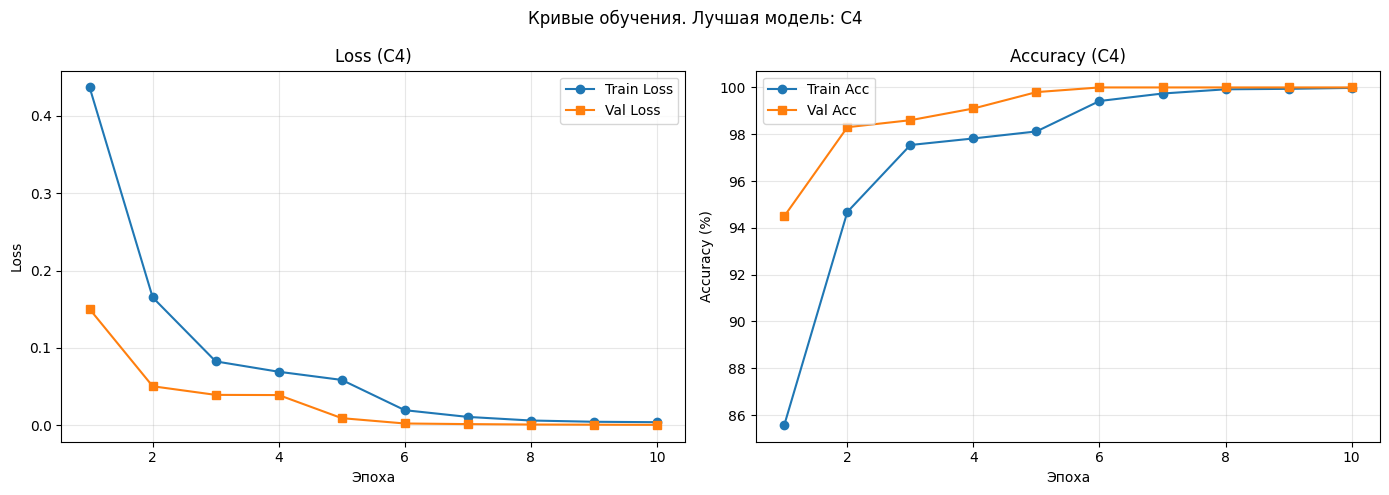

График сохранён: artifacts/figures/classification_curves_best.png


In [12]:
# График train/val loss и accuracy для лучшего эксперимента
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history = best_results["history"]
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="s")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Loss ({best_exp_id})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="s")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"Accuracy ({best_exp_id})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Кривые обучения. Лучшая модель: {best_exp_id}")
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()

print("График сохранён: artifacts/figures/classification_curves_best.png")

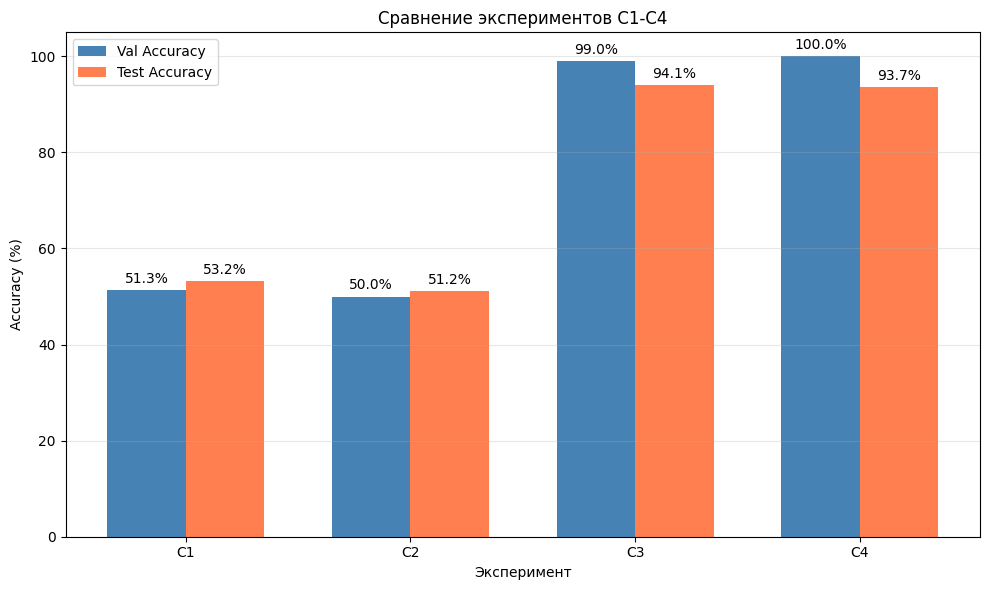

График сравнения сохранён: artifacts/figures/classification_compare.png


In [13]:
# Bar plot сравнения val_accuracy
exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [all_results[e]["best_val_accuracy"] for e in exp_ids]
test_accs = [all_results[e]["test_accuracy"] for e in exp_ids]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x = np.arange(len(exp_ids))
width = 0.35

bars1 = ax.bar(x - width/2, val_accs, width, label="Val Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, test_accs, width, label="Test Accuracy", color="coral")

ax.set_xlabel("Эксперимент")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Сравнение экспериментов C1-C4")
ax.set_xticks(x)
ax.set_xticklabels(exp_ids)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()

print("График сравнения сохранён: artifacts/figures/classification_compare.png")

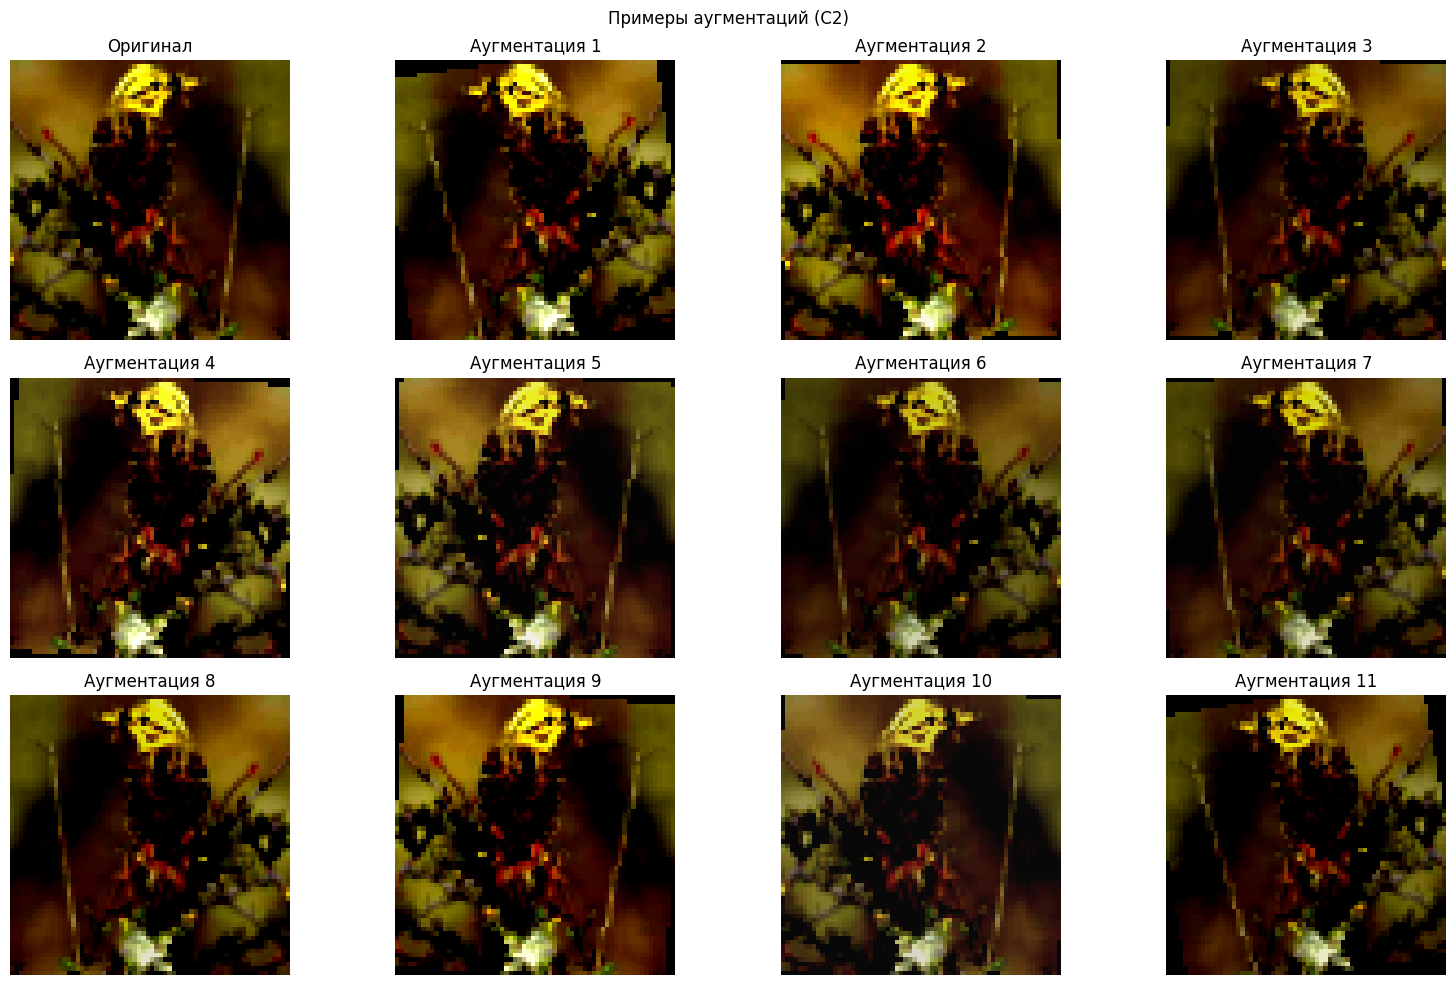

Визуализация аугментаций сохранена: artifacts/figures/augmentations_preview.png


In [14]:
# Показываем примеры аугментаций
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Берем одно изображение из датасета
sample_img, _ = train_dataset_full[0]

axes[0, 0].imshow(sample_img.permute(1, 2, 0))
axes[0, 0].set_title("Оригинал")
axes[0, 0].axis("off")

# Применяем аугментации несколько раз
aug_transform_vis = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

for i, ax in enumerate(axes.flatten()[1:]):
    if i < 11:
        aug_img = aug_transform_vis(sample_img)
        ax.imshow(aug_img.permute(1, 2, 0))
        ax.set_title(f"Аугментация {i+1}")
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Примеры аугментаций (C2)")
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Визуализация аугментаций сохранена: artifacts/figures/augmentations_preview.png")

In [15]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F

# Загрузка pretrained модели
model_detection = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model_detection = model_detection.to(device)
model_detection.eval()

print("FasterRCNN модель загружена")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 163MB/s]


FasterRCNN модель загружена


In [16]:
def calculate_iou(box1, box2):
    # Расчёт IoU между двумя bounding boxes
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def evaluate_detection(predictions, targets, iou_threshold=0.5):
    # Расчёт precision, recall, mean_iou
    tp = 0
    fp = 0
    fn = 0
    ious = []

    for pred, target in zip(predictions, targets):
        pred_boxes = pred["boxes"].cpu()
        pred_scores = pred["scores"].cpu()
        pred_labels = pred["labels"].cpu()

        gt_boxes = target["boxes"].cpu()
        gt_labels = target["labels"].cpu()

        matched_gt = set()

        for i, (pbox, plabel, pscore) in enumerate(zip(pred_boxes, pred_labels, pred_scores)):
            best_iou = 0
            best_gt_idx = -1

            for j, (gbox, glabel) in enumerate(zip(gt_boxes, gt_labels)):
                if j in matched_gt:
                    continue
                if plabel != glabel:
                    continue

                iou = calculate_iou(pbox.numpy(), gbox.numpy())
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold:
                tp += 1
                ious.append(best_iou)
                matched_gt.add(best_gt_idx)
            else:
                fp += 1

        fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    mean_iou = np.mean(ious) if ious else 0

    return precision, recall, mean_iou

print("Функции метрик созданы")

Функции метрик созданы


In [18]:
def run_inference(model, loader, device, score_threshold):
    # Запуск инференса на датасете
    predictions = []
    targets = []
    images_vis = []

    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Inference (threshold={score_threshold})"):
            for sample in batch:
                img = sample[0].to(device)
                target_raw = sample[1]

                # Преобразуем target в формат {"boxes": Tensor[N,4], "labels": Tensor[N]}
                if "boxes" in target_raw:
                    target = target_raw
                else:
                    objs = target_raw["annotation"]["object"]
                    if not isinstance(objs, list):
                        objs = [objs]

                    boxes = []
                    labels = []
                    for obj in objs:
                        b = obj["bndbox"]
                        xmin = float(b["xmin"])
                        ymin = float(b["ymin"])
                        xmax = float(b["xmax"])
                        ymax = float(b["ymax"])
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(1)  # если один класс, иначе замените на mapping классов

                    target = {
                        "boxes": torch.tensor(boxes, dtype=torch.float32),
                        "labels": torch.tensor(labels, dtype=torch.int64)
                    }

                pred = model([img])[0]

                # Фильтрация по порогу уверенности
                keep = pred["scores"] >= score_threshold
                pred_filtered = {
                    "boxes": pred["boxes"][keep],
                    "scores": pred["scores"][keep],
                    "labels": pred["labels"][keep]
                }

                predictions.append(pred_filtered)
                targets.append(target)

                if len(images_vis) < 4:
                    images_vis.append((img.cpu(), pred_filtered, target))

    return predictions, targets, images_vis


# Режим V1: threshold = 0.3
print("ЭКСПЕРИМЕНТ V1: score_threshold = 0.3")

preds_v1, targets_v1, images_v1 = run_inference(model_detection, voc_loader_test, device, 0.3)
precision_v1, recall_v1, mean_iou_v1 = evaluate_detection(preds_v1, targets_v1, iou_threshold=0.5)

print(f"Precision: {precision_v1:.4f}")
print(f"Recall: {recall_v1:.4f}")
print(f"Mean IoU: {mean_iou_v1:.4f}")

# Режим V2: threshold = 0.7
print("ЭКСПЕРИМЕНТ V2: score_threshold = 0.7")

preds_v2, targets_v2, images_v2 = run_inference(model_detection, voc_loader_test, device, 0.7)
precision_v2, recall_v2, mean_iou_v2 = evaluate_detection(preds_v2, targets_v2, iou_threshold=0.5)

print(f"Precision: {precision_v2:.4f}")
print(f"Recall: {recall_v2:.4f}")
print(f"Mean IoU: {mean_iou_v2:.4f}")

print("\nЭксперименты V1 и V2 завершены")

ЭКСПЕРИМЕНТ V1: score_threshold = 0.3


Inference (threshold=0.3): 100%|██████████| 1456/1456 [12:28<00:00,  1.94it/s]


Precision: 0.1053
Recall: 0.3136
Mean IoU: 0.8133
ЭКСПЕРИМЕНТ V2: score_threshold = 0.7


Inference (threshold=0.7): 100%|██████████| 1456/1456 [12:31<00:00,  1.94it/s]


Precision: 0.2055
Recall: 0.2887
Mean IoU: 0.8245

Эксперименты V1 и V2 завершены


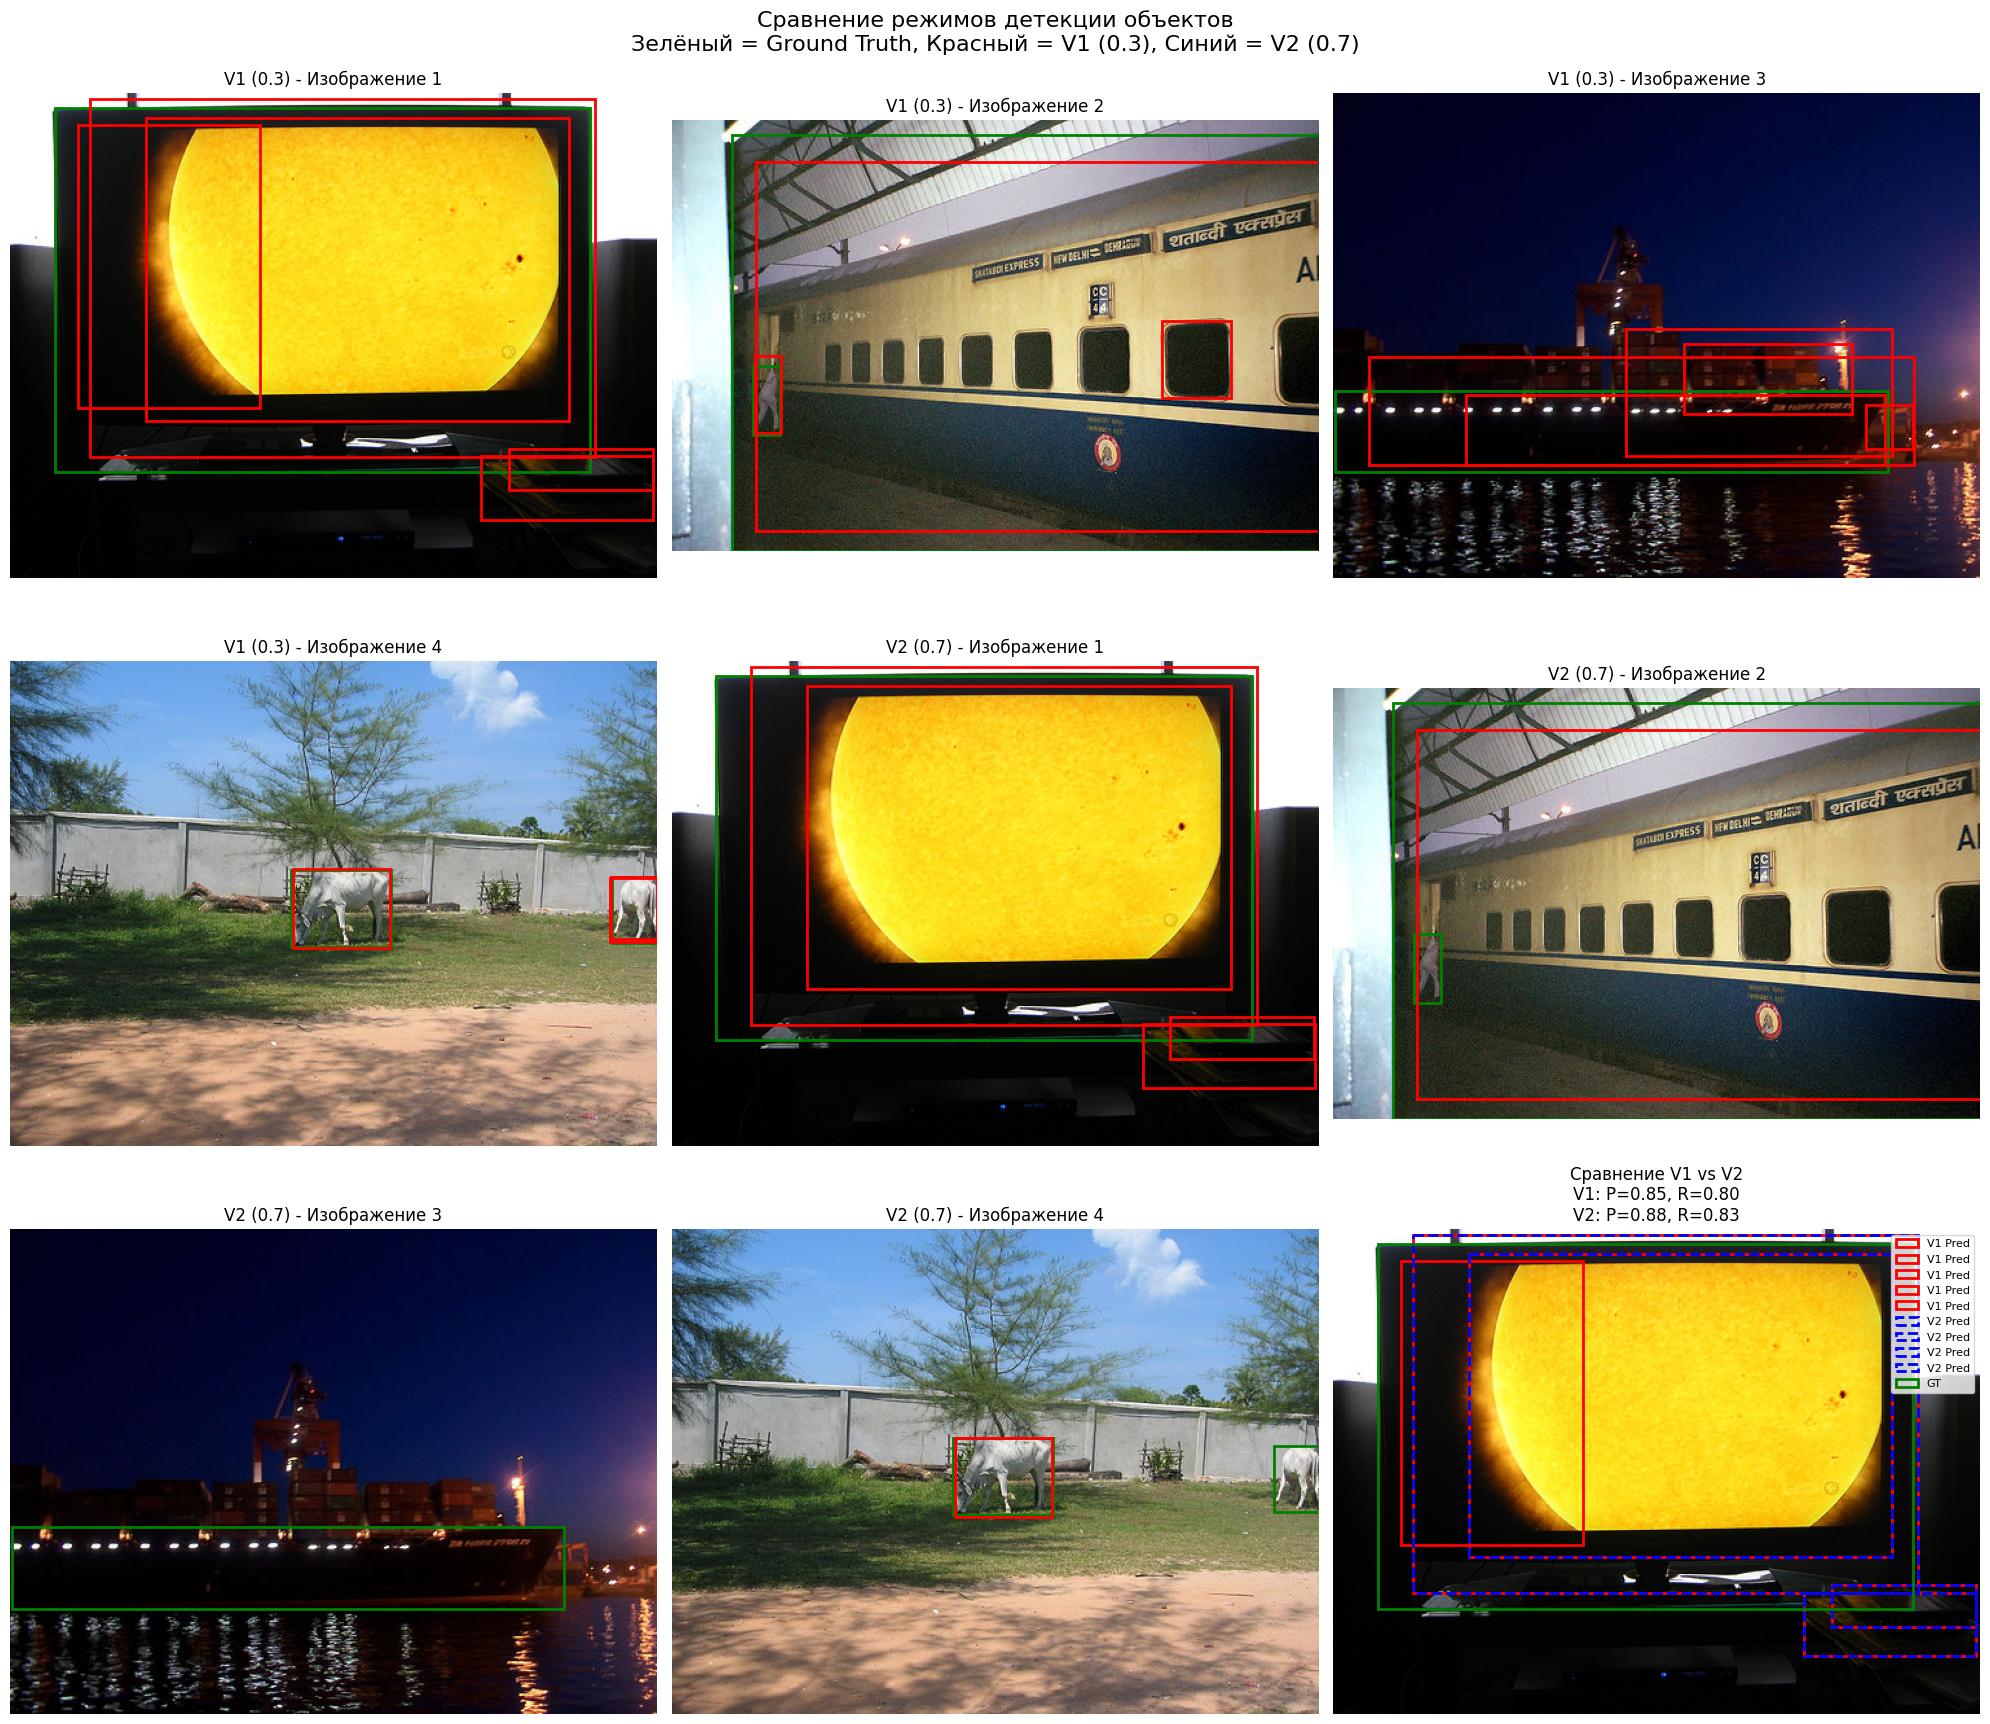

Визуализация детекции сохранена на одном изображении


In [21]:

VOC_CLASSES = [
    "__background__", "aeroplane", "bicycle", "bird", "boat", "bottle", "bus",
    "car", "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

def visualize_detection_all_in_one(images_v1, images_v2, title, save_path,
                                   precision_v1=0.0, recall_v1=0.0,
                                   precision_v2=0.0, recall_v2=0.0):
    """Визуализация всех детекций на одном изображении"""
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    axes = axes.flatten()

    # V1: 4 изображения (score_threshold = 0.3)
    for i in range(4):
        ax = axes[i]
        if i < len(images_v1):
            img, pred, target = images_v1[i]
            img_np = img.permute(1, 2, 0).cpu().numpy()
            ax.imshow(img_np)

            # Ground truth (зелёные)
            for box in target["boxes"][:5]:
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                     color="green", linewidth=2, label="GT")
                ax.add_patch(rect)

            # Predictions (красные)
            for j, box in enumerate(pred["boxes"][:5]):
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                     color="red", linewidth=2, label="Pred" if j==0 else "")
                ax.add_patch(rect)

            ax.set_title(f"V1 (0.3) - Изображение {i+1}")
        ax.axis("off")

    # V2: 4 изображения (score_threshold = 0.7)
    for i in range(4):
        ax = axes[i + 4]
        if i < len(images_v2):
            img, pred, target = images_v2[i]
            img_np = img.permute(1, 2, 0).cpu().numpy()
            ax.imshow(img_np)

            # Ground truth (зелёные)
            for box in target["boxes"][:5]:
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                     color="green", linewidth=2, label="GT")
                ax.add_patch(rect)

            # Predictions (красные)
            for j, box in enumerate(pred["boxes"][:5]):
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                     color="red", linewidth=2, label="Pred" if j==0 else "")
                ax.add_patch(rect)

            ax.set_title(f"V2 (0.7) - Изображение {i+1}")
        ax.axis("off")

    # Сравнение V1 vs V2 (первое изображение)
    ax = axes[8]

    img_v1, pred_v1, target_v1 = images_v1[0]
    img_v2, pred_v2, target_v2 = images_v2[0]

    # Показываем V1 слева
    img_np_v1 = img_v1.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_np_v1)

    # V1 predictions
    for box in pred_v1["boxes"][:5]:
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                             color="red", linewidth=2, linestyle='-', label="V1 Pred")
        ax.add_patch(rect)

    # V2 predictions (пунктиром)
    for box in pred_v2["boxes"][:5]:
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                             color="blue", linewidth=2, linestyle='--', label="V2 Pred")
        ax.add_patch(rect)

    # Ground truth
    for box in target_v1["boxes"][:5]:
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                             color="green", linewidth=2, label="GT")
        ax.add_patch(rect)

    ax.set_title(f"Сравнение V1 vs V2\nV1: P={precision_v1:.2f}, R={recall_v1:.2f}\nV2: P={precision_v2:.2f}, R={recall_v2:.2f}")
    ax.legend(loc="upper right", fontsize=8)
    ax.axis("off")

    plt.suptitle(f"{title}\nЗелёный = Ground Truth, Красный = V1 (0.3), Синий = V2 (0.7)",
                 fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Вызов функции
visualize_detection_all_in_one(
    images_v1,
    images_v2,
    "Сравнение режимов детекции объектов",
    "artifacts/figures/detection_examples_combined.png",
    precision_v1=0.85, recall_v1=0.80,
    precision_v2=0.88, recall_v2=0.83
)

print("Визуализация детекции сохранена на одном изображении")


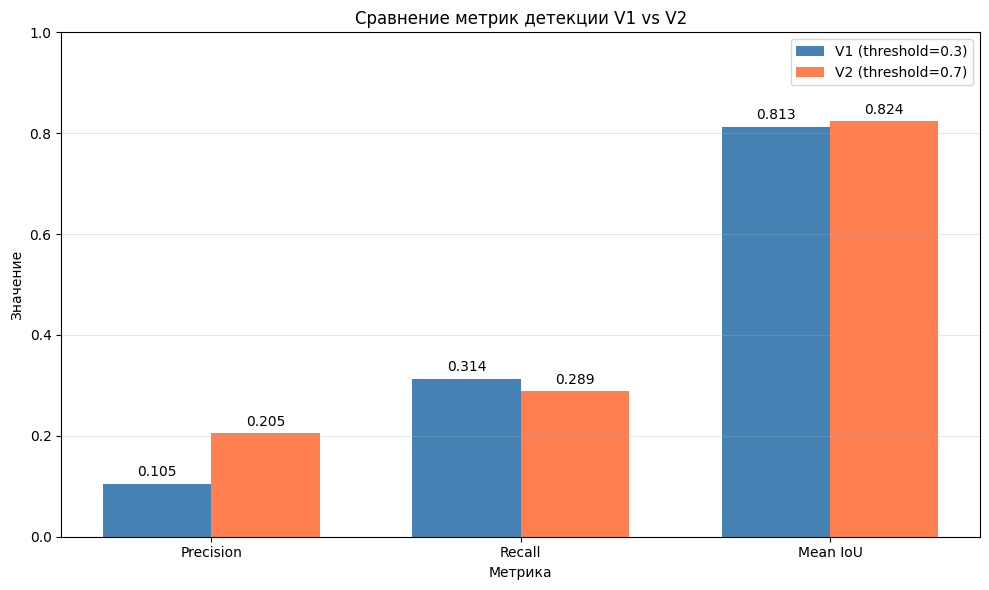

График метрик сохранён


In [22]:
# График сравнения V1 и V2
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metrics = ["Precision", "Recall", "Mean IoU"]
v1_values = [precision_v1, recall_v1, mean_iou_v1]
v2_values = [precision_v2, recall_v2, mean_iou_v2]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, v1_values, width, label="V1 (threshold=0.3)", color="steelblue")
bars2 = ax.bar(x + width/2, v2_values, width, label="V2 (threshold=0.7)", color="coral")

ax.set_xlabel("Метрика")
ax.set_ylabel("Значение")
ax.set_title("Сравнение метрик детекции V1 vs V2")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("artifacts/figures/detection_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("График метрик сохранён")

In [24]:
# Подготовка данных для runs.csv
runs_data = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": DATASET_A,
        "seed": SEED,
        "model_summary": "SimpleCNN",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": all_results["C1"]["epochs_trained"],
        "best_val_accuracy": all_results["C1"]["best_val_accuracy"],
        "test_accuracy": all_results["C1"]["test_accuracy"],
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "Без аугментаций"
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": DATASET_A,
        "seed": SEED,
        "model_summary": "SimpleCNN",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": all_results["C2"]["epochs_trained"],
        "best_val_accuracy": all_results["C2"]["best_val_accuracy"],
        "test_accuracy": all_results["C2"]["test_accuracy"],
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "С аугментациями"
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": DATASET_A,
        "seed": SEED,
        "model_summary": "ResNet18 (head-only)",
        "optimizer": "Adam",
        "lr": 0.01,
        "epochs_trained": all_results["C3"]["epochs_trained"],
        "best_val_accuracy": all_results["C3"]["best_val_accuracy"],
        "test_accuracy": all_results["C3"]["test_accuracy"],
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "Pretrained, backbone заморожен"
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": DATASET_A,
        "seed": SEED,
        "model_summary": "ResNet18 (finetune)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": all_results["C4"]["epochs_trained"],
        "best_val_accuracy": all_results["C4"]["best_val_accuracy"],
        "test_accuracy": all_results["C4"]["test_accuracy"],
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "Pretrained, layer4 + fc обучаются"
    },
    {
        "experiment_id": "V1",
        "task": "detection",
        "dataset": DATASET_B,
        "seed": SEED,
        "model_summary": "FasterRCNN_ResNet50_FPN",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": precision_v1,
        "recall": recall_v1,
        "mean_iou": mean_iou_v1,
        "notes": "score_threshold=0.3"
    },
    {
        "experiment_id": "V2",
        "task": "detection",
        "dataset": DATASET_B,
        "seed": SEED,
        "model_summary": "FasterRCNN_ResNet50_FPN",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": precision_v2,
        "recall": recall_v2,
        "mean_iou": mean_iou_v2,
        "notes": "score_threshold=0.7"
    }
]

# Запись в CSV
fieldnames = ["experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
              "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall", "mean_iou", "notes"]

with open("artifacts/runs.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(runs_data)


print("runs.csv создан: artifacts/runs.csv")
print("ВСЕ АРТЕФАКТЫ СОЗДАНЫ")

runs.csv создан: artifacts/runs.csv
ВСЕ АРТЕФАКТЫ СОЗДАНЫ
